**Week 3**

Date: 2025/7/17 

Objectives this week: 
- ABC posterior estimation with traditional rejection sampling and MCMC.
    - 1D and 2D
- mini falcon exploration and experiments
- experiments with known optimal summary statistics models
    - 1D and 2D Gaussian (known mean and variance/covariance)
    - Poisson (known rate)
    - Exponential (known scale parameters)
    - Compare NN learned and analytical summary statistics for each model

**ABC posterior estimation with rejection and MCMC sampling**

arithemetic mean value found using ABC with rejection algorithm: tensor(0.4850)


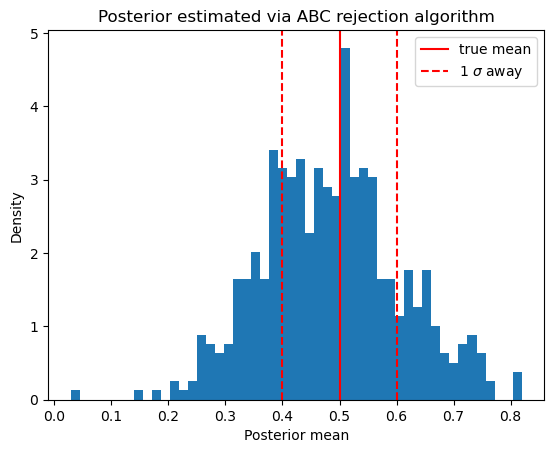

In [2]:
# 1D with rejection sampling
import torch
from sbi import utils as utils
import matplotlib.pyplot as plt
import numpy as np
torch.random.manual_seed(13)

num_dim = 1
num_points = 10000
true_theta = 0.5 *torch.ones(num_dim)
true_sd = 0.1 *torch.ones(num_dim)
x_obs = torch.normal(mean=true_theta, std=true_sd)

prior = utils.BoxUniform(low=-2*torch.ones(num_dim), high=2*torch.ones(num_dim))

def simulator(theta):
    return theta + true_sd * torch.randn_like(theta)

# in 1D case, reject x_sim points if > true_sd away from x_obs

def rejection(x_obs, prior, epsilon=true_sd, N=num_points):
    accept = []  # to store accepted theta's

    for _ in range(N):
        theta = prior.sample((1,))
        x_sim = simulator(theta)
        if torch.norm(x_sim - x_obs) < epsilon:
            accept.append(theta)
    return torch.cat(accept, dim=0)
            
posterior = rejection(x_obs, prior)
print('arithemetic mean value found using ABC with rejection algorithm:',torch.mean(posterior))

plt.figure()
plt.hist(posterior, density=True, bins=50)
plt.xlabel('Posterior mean')
plt.ylabel('Density')
plt.title('Posterior estimated via ABC rejection algorithm')
plt.axvline(x=0.5, color='red', label='true mean')
plt.axvline(x=0.4, color='red', ls='--', label='1 $\sigma$ away')
plt.axvline(x=0.6, color='red', ls='--')
# plt.xlim(-2,2)
plt.legend()
plt.show()

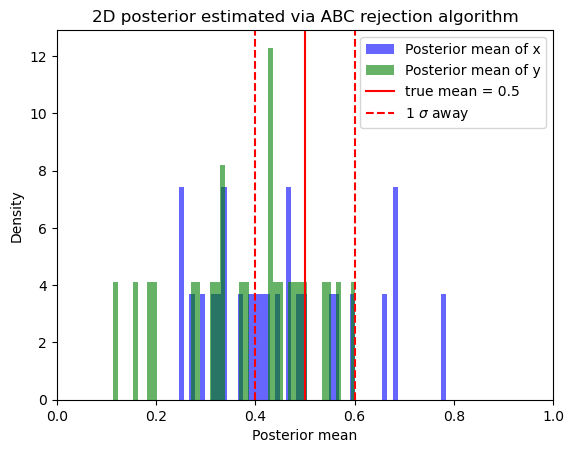

In [63]:
# 2D with rejection
torch.random.manual_seed(13)

num_dim = 2
num_points = 10000**2
true_theta = 0.5 * torch.ones(num_dim)
true_sd = 0.1 * torch.ones(num_dim)
x_obs_2D = torch.normal(mean=true_theta, std=true_sd)

prior_2D = utils.BoxUniform(low=-2*torch.ones(num_dim), high=2*torch.ones(num_dim))

posterior_2D = rejection(x_obs_2D, prior_2D)

x, y = [], []
for vector in posterior_2D:
    x.append(vector[0])
    y.append(vector[1])

plt.figure()
plt.hist(x, density=True, bins=50, color='blue', alpha=0.6, label='Posterior mean of x')
plt.hist(y, density=True, bins=50, color='green', alpha=0.6, label='Posterior mean of y')
plt.xlabel('Posterior mean')
plt.ylabel('Density')
plt.title('2D posterior estimated via ABC rejection algorithm')
plt.axvline(x=0.5, color='red', label='true mean = 0.5')
plt.axvline(x=0.4, color='red', ls='--', label='1 $\sigma$ away')
plt.axvline(x=0.6, color='red', ls='--')
plt.xlim(0,1)
plt.legend()
plt.show()

2D version seems to be converging less well than 1D, even though the number of data points is squared, with the mean in y (2nd dimension) deviating to about 0.42. Noticeably a lot fewer points pass the rejection method in this 2D algorithm as the algo becomes more sensitive to deviations in simulated data.
Curse of dimensionality already showing its power in 2D!?

In [ ]:
# with MCMC
import sbi
from sbi.inference import SNPE, simulate_for_sbi, prepare_for_sbi
from sbi import analysis as analysis
import torch
torch.random.manual_seed(13)
from sbi import utils as utils

# 1D case
num_dim = 1
num_points = 100000
true_theta = 0.5 *torch.ones(num_dim)
true_sd = 0.1 *torch.ones(num_dim)
x_obs = torch.normal(mean=true_theta, std=true_sd)

prior = utils.BoxUniform(low=-2*torch.ones(num_dim), high=2*torch.ones(num_dim))
simulator, prior = prepare_for_sbi(simulator, prior)
theta_1D, x_1D = simulate_for_sbi(simulator, prior, num_simulations=num_points)

inference = SNPE(prior=prior)
DE = inference.append_simulations(theta_1D, x_1D).train()
# sampling wirh MCMC
sampling_algorithm = "mcmc"
mcmc_method = "slice_np"
posterior_1D_MCMC = inference.build_posterior(sample_with=sampling_algorithm, 
                                              mcmc_method=mcmc_method,
                                              mcmc_parameters={"num_chains": 1, "thin": 1, "warmup_steps": 100})


Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 54 epochs.

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/10100 [00:00<?, ?it/s]

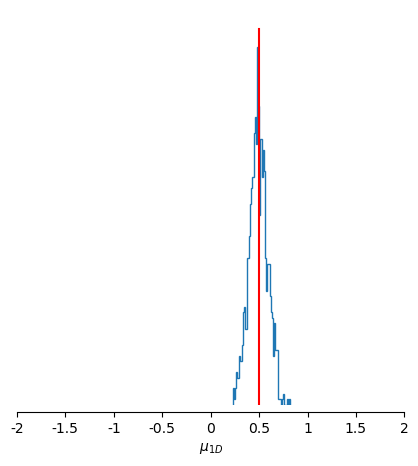

In [75]:
sample_1D = posterior_1D_MCMC.set_default_x(x_obs).sample((1000,))
fig, ax = analysis.pairplot(
    sample_1D,
    points=true_theta,
    points_colors='r',
    labels=["$\mu_{1D}$"],
    limits=[[-2,2]],
    figsize=(5, 5),
)

NPE learned posterior with MCMC sampling method obviously give a much better convergence and estimate of the true parameter, however the runtime is much longer for collecting a data size of 1000.

In [3]:
# 1D ABC MCMC
import torch
torch.random.manual_seed(13)

true_theta = torch.tensor([0.5])
x_obs = simulator(true_theta)

num_points = 1000
epsilon = 0.05   #ABC threshold
sd = 0.1
theta_chain = []

theta_init = torch.rand(1)

for _ in range(num_points):
    theta_prop = theta_init + sd * torch.randn(1)   #choose theta_prop in 1 sd away from the theta_init
    x_sim = simulator(theta_prop)
    d = torch.norm(x_sim - x_obs)

    if d < epsilon:
        theta_init = theta_prop

    theta_chain.append(theta_init)


c:\Users\boat\anaconda3\envs\sbi-features\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


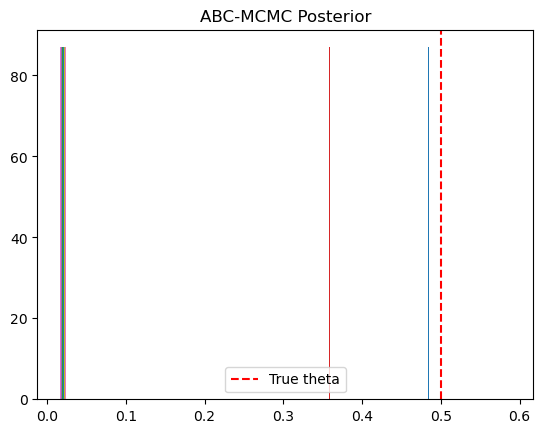

In [5]:
import matplotlib.pyplot as plt
plt.hist(theta_chain, bins=50, density=True)  
plt.axvline(x=0.5, color='red', ls='--', label='True theta')
plt.title('ABC-MCMC Posterior')
plt.legend()
plt.show()

**Learned sumamry stats vs optimal summaries** 
- 1D/2D Gaussian, summary stats are either the mean (with known std in 1D) or the covariance matrix (with known mean in 2D)
- Poisson and Exponential, summary stats are both the sum of samples $T = \sum^n_i x_i$, where $\lambda_{Poisson} = T/n $ and $\lambda_{Exponential} = n / T$


In [ ]:
# 1D Gaussian (mean and variance estimation)
import torch
from sbi import utils as utils
from sbi.inference import simulate_for_sbi
from sbi.utils.user_input_checks import prepare_for_sbi
from sbi.inference import SNPE
import matplotlib.pyplot as plt
import numpy as np
from sbi.neural_nets import posterior_nn
import torch.nn as nn
import torch.nn.functional as F

torch.random.manual_seed(13)

# parameters
dim = 1
n_obs = 10000
prior = torch.distributions.Normal(loc=torch.zeros(dim), scale=torch.ones(dim) * 0.05)
sim_sd = torch.ones(dim) * 0.1

def simulator(theta):
    return torch.normal(theta, sim_sd).expand(-1,n_obs)

# embedding network
class embedding_network(nn.Module):
    def __init__(self, input_dim, embedding_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, embedding_dim),
            # nn.ReLU()    ReLU forces non-negative output that may cause interference with true outcomes
        )

    def forward(self, x):
        return self.network(x)

# training sbi
def train_sbi(net, num_simulations=n_obs):
    sim, pri = prepare_for_sbi(simulator, prior)
    theta, x = simulate_for_sbi(sim, pri, num_simulations=num_simulations)
    x = x.view(x.shape[0], -1)  # reshape x

    nn_estimator = posterior_nn(model='maf', embedding_net=net)
    inference = SNPE(prior=pri, density_estimator=nn_estimator)
    de = inference.append_simulations(theta, x).train()
    posterior = inference.build_posterior(de)

    return posterior, net, theta, x

# analysis, extract learned summary stats
class analyze_embeddings:
    def __init__(self, embedding_net, x_eval, optimal_summary):
        self.embedding_net = embedding_net
        self.eval_x = x_eval
        self.optimal_summary = optimal_summary
        self.analyze()

    def analyze(self):
        with torch.no_grad():
            # flatten x
            if self.eval_x.ndim > 2:
                x_flat = self.eval_x.view(self.eval_x.shape[0], -1)
            else:
                x_flat = self.eval_x

            # learned + optimal summaries
            learned_summary = self.embedding_net(x_flat)
            optimal_summary = self.optimal_summary(self.eval_x)

            # cosine similarity
            learned_norm = F.normalize(learned_summary, dim=1)
            optimal_norm = F.normalize(optimal_summary, dim=1)
            cosine_sim = torch.sum(learned_norm * optimal_norm, dim=1).mean().item()

            # correlation
            if learned_summary.shape[1] > 1:
                corr = torch.corrcoef(torch.stack([
                    learned_summary[:, 0],
                    optimal_summary.squeeze()
                ]))[0, 1].item()
            else:
                corr = torch.corrcoef(torch.stack([
                    learned_summary.squeeze(),
                    optimal_summary.squeeze()
                ]))[0, 1].item()

            print(f"Cosine similarity: {cosine_sim:.4f}")
            print(f"Pearson correlation (1st comp vs optimal): {corr:.4f}")

            self.cosine_similarity = cosine_sim
            self.correlation = corr

# experiment
def gaussian_mean_experiment():
    def optimal_summary(x):
        return x.mean(dim=1, keepdim=True)

    embedding_dims = [1, 2, 4, 8]
    results = {}

    for dim_embed in embedding_dims:
        print(f"\n Training with embedding_dim = {dim_embed}")
        embed_net = embedding_network(input_dim=n_obs, embedding_dim=dim_embed)
        posterior, net, theta, x = train_sbi(embed_net, num_simulations=n_obs)
        analysis = analyze_embeddings(net, x[:100], optimal_summary)
        results[dim_embed] = {
            "cosine_similarity": analysis.cosine_similarity,
            "correlation": analysis.correlation
        }

    return results

gaussian_mean_experiment()



 Training with embedding_dim = 1


C:\Users\boat\AppData\Local\Temp\ipykernel_11872\2760056079.py:40: DeprecationWarning: This method is deprecated as of sbi version v0.23.0. and will be removed in a         future release.Please use `process_prior` and `process_simulator` in the future.
  sim, pri = prepare_for_sbi(simulator, prior)


  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 36 epochs.Cosine similarity: -0.9800
Pearson correlation (1st comp vs optimal): -0.9892

 Training with embedding_dim = 2


  0%|          | 0/10000 [00:00<?, ?it/s]

...

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 121 epochs.Cosine similarity: 0.3049
Pearson correlation (1st comp vs optimal): -0.9619

 Training with embedding_dim = 8


  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 40 epochs.Cosine similarity: 0.4515
Pearson correlation (1st comp vs optimal): 0.8224


{1: {'cosine_similarity': -0.9800000190734863,
  'correlation': -0.9892263412475586},
 2: {'cosine_similarity': 0.09462510794401169,
  'correlation': 0.9766041040420532},
 4: {'cosine_similarity': 0.3049263656139374,
  'correlation': -0.9619131088256836},
 8: {'cosine_similarity': 0.45152077078819275,
  'correlation': 0.8223519325256348}}

In [99]:
# convert scipt.stats.invwishart to torch forms
import torch
from torch.distributions import Distribution
from torch.distributions import constraints
from torch.special import multigammaln

class InverseWishart(Distribution):
    arg_constraints = {'df': constraints.positive, 'scale': constraints.positive_definite}
    support = constraints.positive_definite
    has_rsample = False

    def __init__(self, df, scale, validate_args=None):
        self.df = df
        self.scale = scale
        self.dim = scale.shape[-1]
        super().__init__(batch_shape=torch.Size(), event_shape=scale.shape, validate_args=validate_args)

    def sample(self, sample_shape=torch.Size()):
        sample_shape = torch.Size(sample_shape)
        n_samples = int(torch.tensor(sample_shape).numel()) if len(sample_shape) > 0 else 1

        samples = []
        scale_inv = torch.linalg.inv(self.scale)
        chol = torch.linalg.cholesky(scale_inv)

        for _ in range(n_samples):
            A = torch.zeros((self.dim, self.dim))
            for i in range(self.dim):
                A[i, i] = torch.sqrt(torch.distributions.Chi2(self.df - i).sample())
                for j in range(i):
                    A[i, j] = torch.randn(())
            LA = chol @ A
            W = LA @ LA.T
            IW = torch.linalg.inv(W)
            samples.append(IW)

        stacked = torch.stack(samples)
        return stacked.view(*sample_shape, self.dim, self.dim)

    def log_prob(self, x):
        sign_x, logdet_x = torch.slogdet(x)
        sign_scale, logdet_scale = torch.slogdet(self.scale)
        trace_term = torch.trace(self.scale @ torch.linalg.inv(x))

        log2 = torch.log(torch.tensor(2.0, dtype=logdet_scale.dtype, device=logdet_scale.device))
        df_half = torch.tensor(self.df / 2, dtype=logdet_scale.dtype, device=logdet_scale.device)

        norm_const = (
            -0.5 * self.df * logdet_scale
            - 0.5 * self.df * self.dim * log2
            - multigammaln(df_half, self.dim)
        )

        log_pdf = norm_const - 0.5 * (self.df + self.dim + 1) * logdet_x - 0.5 * trace_term
        return log_pdf


In [101]:
# 2D - known mean, learned covariance 
import numpy as np
from scipy.stats import invwishart

# parameter + function defining
dim = 2
df  = 5
n_obs = 10000
scale = torch.eye(dim, dtype=torch.float32) * 0.05

prior_invwishart = InverseWishart(df=df, scale=scale)

cov = prior_invwishart.sample((n_obs,))     #sample covariance matrix from prior 
x_mean = torch.zeros(dim, dtype=torch.float32)   #known mean

def simulator_2d_gaussian(cov_matrix_batch):
    samples = []
    for i in range(cov_matrix_batch.shape[0]):
        mvn = torch.distributions.MultivariateNormal(x_mean, covariance_matrix=cov_matrix_batch[i])
        samples.append(mvn.sample())
    return torch.stack(samples)

# training sbi
def train_sbi(net, num_simulations=n_obs):
    sim, pri = prepare_for_sbi(simulator_2d_gaussian, prior_invwishart)
    theta, x = simulate_for_sbi(sim, pri, num_simulations=num_simulations)
    x = x.view(x.shape[0], -1)  # reshape x

    nn_estimator = posterior_nn(model='maf', embedding_net=net)
    inference = SNPE(prior=pri, density_estimator=nn_estimator)
    de = inference.append_simulations(theta, x).train()
    posterior = inference.build_posterior(de)

    return posterior, net, theta, x

# experiment
def gaussian_mean_experiment():
    def optimal_summary(x):
        return x.cov(dim=dim, keepdim=True)

    embedding_dims = [1, 2, 4, 8]
    results = {}

    for dim_embed in embedding_dims:
        print(f"\n Training with embedding_dim = {dim_embed}")
        embed_net = embedding_network(input_dim=n_obs, embedding_dim=dim_embed)
        posterior, net, theta, x = train_sbi(embed_net, num_simulations=n_obs)
        analysis = analyze_embeddings(net, x[:100], optimal_summary)
        results[dim_embed] = {
            "cosine_similarity": analysis.cosine_similarity,
            "correlation": analysis.correlation
        }

    return results

gaussian_mean_experiment()


RuntimeError: shape '[10000, 2, 2]' is invalid for input of size 4

In [ ]:
# Without using a learning network
# Poisson with known rate, lambda
import torch 
torch.random.manual_seed(13)

n_obs = [10, 100, 1000]
rate = 3.0   #known lambda

def poisson_est(n):
    x_poisson = torch.poisson(torch.full((n,), rate))
    summary_poisson = x_poisson.sum()
    rate_poisson = summary_poisson / n
    return summary_poisson, rate_poisson

print('Poisson results:')
for n in n_obs:
    summary_poisson, rate_poisson = poisson_est(n)
    print(f'with n = {n}, summary statistics = {summary_poisson} which gives an estimate of lambda = {rate_poisson}')
print('--------------------'
'\nExponential results:')

# Exponential with known scale lambda, to find summary stats sum(x)
# using the same n and lambda as Poisson

def exp_est(n):
    x_exp = torch.distributions.Exponential(rate).sample((n,))
    summary_exp = x_exp.sum()
    rate_exp = n / summary_exp   #sum(x) = 1/lambda for exponential dist
    return summary_exp, rate_exp

for n in n_obs:
    summary_exp, rate_exp = exp_est(n)
    print(f'with n = {n}, summary statistics found is {summary_exp} which gives an estimate of lambda = {rate_exp}')

print('better convergence to true lambda = 3.0 seen at large n!')

Poisson results:
with n = 10, summary statistics = 27.0 which gives an estimate of lambda = 2.700000047683716
with n = 100, summary statistics = 275.0 which gives an estimate of lambda = 2.75
with n = 1000, summary statistics = 2989.0 which gives an estimate of lambda = 2.989000082015991
--------------------
Exponential results:
with n = 10, summary statistics found is 4.22169303894043 which gives an estimate of lambda = 2.368717908859253
with n = 100, summary statistics found is 30.09868812561035 which gives an estimate of lambda = 3.322403907775879
with n = 1000, summary statistics found is 339.4067687988281 which gives an estimate of lambda = 2.946317195892334
better convergence to true lambda = 3.0 seen at large n!


In [104]:
# Using learning networks 
# Poisson
from sbi import utils
torch.manual_seed(13)

dim = 1
n_obs = 10000
prior_poisson = utils.BoxUniform(low=torch.tensor([0.0]), high=torch.tensor([5.0]))   #uniform prior for lambda (rate)


def simulator_poisson(rate):
    return torch.poisson(rate.expand(n_obs))


def train_sbi(net, num_simulations=n_obs):
    sim, pri = prepare_for_sbi(simulator_poisson, prior_poisson)
    theta, x = simulate_for_sbi(sim, pri, num_simulations=num_simulations)
    x = x.view(x.shape[0], -1)  #reshape x

    nn_estimator = posterior_nn(model='maf', embedding_net=net)
    inference = SNPE(prior=pri, density_estimator=nn_estimator)
    de = inference.append_simulations(theta, x).train()
    posterior = inference.build_posterior(de)

    return posterior, net, theta, x

def poisson_rate_experiment():
    def optimal_summary(x):
        return x.sum(dim=dim, keepdim=True)    #summary stats = sum(x) for Poisson

    embedding_dims = [1, 2, 4, 8]
    results = {}

    for dim_embed in embedding_dims:
        print(f"\n Training with embedding_dim = {dim_embed}")
        embed_net = embedding_network(input_dim=n_obs, embedding_dim=dim_embed)
        posterior, net, theta, x = train_sbi(embed_net, num_simulations=n_obs)
        analysis = analyze_embeddings(net, x[:100], optimal_summary)
        results[dim_embed] = {
            "cosine_similarity": analysis.cosine_similarity,
            "correlation": analysis.correlation
        }

    return results

poisson_rate_experiment()


 Training with embedding_dim = 1


C:\Users\boat\AppData\Local\Temp\ipykernel_11872\1399207481.py:16: DeprecationWarning: This method is deprecated as of sbi version v0.23.0. and will be removed in a         future release.Please use `process_prior` and `process_simulator` in the future.
  sim, pri = prepare_for_sbi(simulator_poisson, prior_poisson)


  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 57 epochs.Cosine similarity: -1.0000
Pearson correlation (1st comp vs optimal): -0.9999

 Training with embedding_dim = 2


  0%|          | 0/10000 [00:00<?, ?it/s]

...

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 37 epochs.Cosine similarity: -0.3461
Pearson correlation (1st comp vs optimal): -0.9997

 Training with embedding_dim = 8


  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 66 epochs.Cosine similarity: -0.7896
Pearson correlation (1st comp vs optimal): -0.9998


{1: {'cosine_similarity': -1.0, 'correlation': -0.9998772144317627},
 2: {'cosine_similarity': -0.8899829983711243,
  'correlation': 0.9583501219749451},
 4: {'cosine_similarity': -0.34607505798339844,
  'correlation': -0.9996903538703918},
 8: {'cosine_similarity': -0.7896007299423218,
  'correlation': -0.9997695684432983}}

In [109]:
#Exponential
n_obs = 10000
dim = 1
prior_exp = utils.BoxUniform(low=torch.tensor([0.1]), high=torch.tensor([5.0]))    #uniform prior for lambda (scale)


def simulator_exp(rate):
    return torch.distributions.Exponential(rate).sample((n_obs,))

def train_sbi(net, num_simulations=n_obs):
    sim, pri = prepare_for_sbi(simulator_exp, prior_exp)
    theta, x = simulate_for_sbi(sim, pri, num_simulations=num_simulations)
    x = x.view(x.shape[0], -1)  #reshape x

    nn_estimator = posterior_nn(model='maf', embedding_net=net)
    inference = SNPE(prior=pri, density_estimator=nn_estimator)
    de = inference.append_simulations(theta, x).train()
    posterior = inference.build_posterior(de)

    return posterior, net, theta, x

def exp_rate_experiment():
    def optimal_summary(x):
        return x.sum(dim=dim, keepdim=True)        #sumamry stats = sum(samples)

    embedding_dims = [1, 2, 4, 8]
    results = {}

    for dim_embed in embedding_dims:
        print(f"\n Training with embedding_dim = {dim_embed}")
        embed_net = embedding_network(input_dim=n_obs, embedding_dim=dim_embed)
        posterior, net, theta, x = train_sbi(embed_net, num_simulations=n_obs)
        analysis = analyze_embeddings(net, x[:100], optimal_summary)
        results[dim_embed] = {
            "cosine_similarity": analysis.cosine_similarity,
            "correlation": analysis.correlation
        }

    return results

exp_rate_experiment()


 Training with embedding_dim = 1


C:\Users\boat\AppData\Local\Temp\ipykernel_11872\2220263582.py:11: DeprecationWarning: This method is deprecated as of sbi version v0.23.0. and will be removed in a         future release.Please use `process_prior` and `process_simulator` in the future.
  sim, pri = prepare_for_sbi(simulator_exp, prior_exp)


  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 42 epochs.Cosine similarity: -1.0000
Pearson correlation (1st comp vs optimal): -0.9996

 Training with embedding_dim = 2


  0%|          | 0/10000 [00:00<?, ?it/s]

...

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 55 epochs.Cosine similarity: -0.3834
Pearson correlation (1st comp vs optimal): 0.9995

 Training with embedding_dim = 8


  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 61 epochs.Cosine similarity: 1.5392
Pearson correlation (1st comp vs optimal): 0.9998


{1: {'cosine_similarity': -1.0, 'correlation': -0.9996262192726135},
 2: {'cosine_similarity': 0.0876653641462326,
  'correlation': 0.9998570680618286},
 4: {'cosine_similarity': -0.38344869017601013,
  'correlation': 0.9995245337486267},
 8: {'cosine_similarity': 1.5392353534698486,
  'correlation': 0.9997534155845642}}